# Group 2607 Project Presentation

## **Introduction**

### SAT problems

In this project, we worked on the application of QAOA to the classical SAT problems, focusing specifically on the 2-SAT problem while also presenting some brief results for the 3-SAT problem. 

The general k-SAT and 1-in-k-SAT problems represent some of the most used methods to test and benchmark algorithm performance. A single instance consists of a formula containing $m$ clauses with $k$ variables each. These variables are sampled randomly out of $n$ boolean variables and are called literals when used in a clause. Literals must be unique in a clause. They can be either positive or negated.
For example, a 2-SAT problem with $n=6$ and $m=3$ can be represented by the following formula:
\begin{equation*}
\mathcal{F}=[(x_1\lor \neg{x_2})\land(x_3\lor x_6)\land( x_1 \lor \neg x_4)].
\end{equation*}
As mentioned before, the variables used in a formula are sampled uniformly out of the $n$ total available variables. In this specific case with $n=6$, it is clear that $x_5$ was not used. A solution to this problem is a bit string $(x_1,x_2,x_3,x_4,x_5,x_6)$ where a boolean is assigned to each variable in order to satisfy every clause in the formula.
In the case of 1-in-k-SAT problems a constraint is added, forcing the search algorithm to find a bitstring such that every clause contains exactly one True literal.

The crucial question when dealing with SAT problems is the following: given two numbers $n$ and $m$, what is the probability that a formula with $n$ variables and $m$ clauses admits at least one solution? How many solutions exist? This theoretical problem was studied in the last decades and important results came in 2002 with the paper *"Analytic and Algorithmic Solution of Random Satisfiability Problems"* by M. Mezard, G. Parisi, and R. Zecchina, who modeled the problem with a spin glass approach. In the thermodynamic limit $n \rightarrow \infty$, these problems are characterized by a SAT regime, where there exists at least one bitstring that satisfies all clauses, and an UNSAT regime, where no solutions exist. The phase transition between the SAT and UNSAT regime is encountered at specific values of the critical density $\alpha=m/n$. The characteristic critical densities for the 2-SAT and 3-SAT problems are respectively $\alpha_c=1$ and $\alpha_c=4.26$. For finite values of $n$ the transition is smooth due to finite size effects, approaching a step function in the thermodynamic limit.

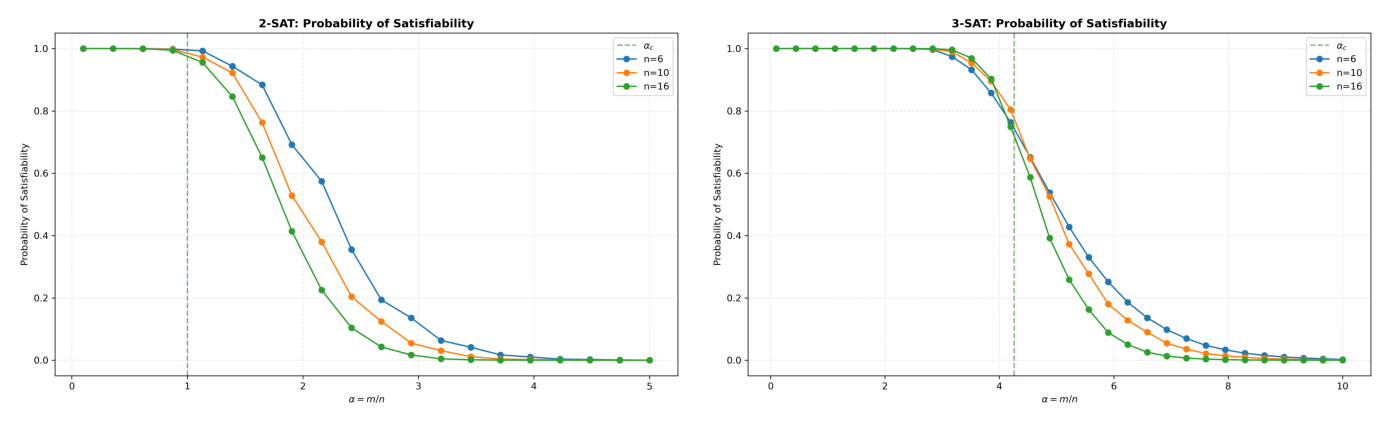

### Quantum Approximate Optimization Algorithm (QAOA)

In our work, the main focus was to study how quantum computing, specifically the Quantum Approximate Optimization Algorithm (QAOA), can be used to tackle these problems, analyzing whether it provides an improvement over classical approaches. QAOA is a hybrid quantum-classical algorithm designed to solve optimization problems. It makes use of a quantum circuit coupled with a classical optimizer. First, the objective function is mapped into a quantum cost Hamiltonian $H_C$. The algorithm then employs a parametrized quantum circuit of depth $p$. The qubits are initialized in a superposition state $| \psi_0 \rangle = | + \rangle^{\otimes n}$, which then evolves through $p$ layers, each depending on two parameters $(\gamma_i, \beta_i)$.

Each layer applies two unitary evolutions: one generated by the cost Hamiltonian $H_C$ and the other by a mixing Hamiltonian $H_B$. This process creates constructive interference, which increases the probability amplitudes of the low-cost solutions.

During each iteration, the parametrized circuit is executed and measured multiple times in the computational basis to estimate the expectation value of the cost Hamiltonian, $\langle H_C \rangle$. Finally, the $2p$ parameters $(\vec{\gamma}, \vec{\beta})$ are updated by a classical optimizer to find the optimal values, and the circuit is run again. This procedure is repeated iteratively until convergence.

When simulating a quantum circuit, the estimation of the cost Hamiltonian can be done in two different ways. One way is to simulate the randomness of the measurement by introducing finite shots, mimicking the behavior of real quantum hardware. The alternative approach, which was adopted in this project, consists of computing the exact analytical expectation value $\langle H_C \rangle$. Since the wavefunction is analytically known, this method completely eliminates statistical noise. A direct consequence of this choice is that the convergence of classical optimizers is significantly facilitated by the increased smoothness of the energy landscape.

## **Formula Generation and Classical Solver**

To generate the formulas, we adopted an object-oriented approach by creating a `kSATGenerator` class. This class takes as parameters the number of literals per clause, `k`, and an optional random seed. To create a formula, the `generate` method must be called with the target number of clauses, `m`, and the total number of variables, `n`. The maximum possible number of clauses is calculated internally to introduce a validation check over the specified `m` value. Every clause is temporarily stored in a `set` to ensure uniqueness, which is then converted into a `list` at the end. A single clause is generated by randomly sampling `k` variables out of the total `n`. Each of these variables is then turned into a literal by randomly multiplying it by $+1$ or $-1$, to indicate its positive or negated state. The example formula presented in the introduction, if generated with this approach, would look like this:

\begin{equation*}
\mathcal{F}=[(1, -2), (3, 6), (1, -4)].
\end{equation*}

```python
class kSATGenerator:
    """Generates random k-SAT formulas."""

    def __init__(self, k, seed=None):
        """
        Args:
            k (int): The number of literals per clause.
            seed (int, optional): Random seed for reproducibility. Defaults to None.
        """
        self.k = k
        self.random = random.Random(seed)

    def generate(self, num_clauses, num_vars):
        """Generates a k-SAT formula with the specified number of clauses and variables.

        Args:
            num_clauses (int): The number of clauses to generate.
            num_vars (int): The total number of available variables.

        Returns:
            list: A list of tuples, where each tuple represents a clause of k literals.
        """
        # Check against the theoretical maximum of unique clauses
        max_num_clauses = 2**self.k * math.comb(num_vars, self.k)
        if num_clauses > max_num_clauses:
            raise ValueError("Too many clauses")
        
        vars_list = list(range(1, num_vars + 1))
        clauses = set()

        # Generate unique clauses using a set to automatically avoid duplicates
        while len(clauses) < num_clauses:
            variables = sorted(self.random.sample(vars_list, self.k))
            
            # Randomly assign positive or negative signs to the chosen variables
            literals = [var * self.random.choice([1, -1]) for var in variables]
            
            clause = tuple(literals)
            clauses.add(clause)

        return list(clauses)
```

### Approaching the problem "classically"

The `brute_force_solve` function takes as an input a formula generated by the `kSATGenerator` function described in the previous section, and implements a brute force approach to look for solutions. Given the number of variables $n$, it tests all the $2^n$ possible bitstrings of length $n$ against the formula. 

A boolean parameter named `one_in_k` can be toggled to solve the 1-in-k-SAT variant, restricting the search to bitstrings that yield exactly one True literal per clause. 

The algorithm makes use of a `for` loop in order to explore the entire solution space. Therefore it is clear that this approach is not scalable for high values of $n$, since the computational complexity scales like $\mathcal{O}(2^n)$. The loop stops when it finds the first valid solution, returning the bitstring satisfying the formula. If no solution has been found throughout the entire loop, it simply returns `None`.

```python
def brute_force_solve(formula, one_in_k=False):
    """Finds a satisfying bitstring for the formula by exhaustively searching all possible states.

    Args:
        formula (list): The SAT formula.
        one_in_k (bool, optional): If True, treats the formula as exactly-1-in-k SAT. Defaults to False.

    Returns:
        str or None: A string representing the satisfying bit assignment (e.g., "1011"), or None if no solution exists.
    """
    num_variables = get_num_variables(formula)
    
    # Iterate through all 2^N possible logical states
    for n in range(2**num_variables):
        violated_count = 0
        
        for clause in formula:
            true_count = 0
            for literal in clause:
                var_index = abs(literal) - 1
                
                # Extract the boolean value using bitwise shifts
                value = (n >> var_index) & 1
                
                # Flip the bit if the literal is negated
                if literal < 0:
                    value = 1 - value
                    
                true_count += value
            
            # Check satisfaction based on the chosen SAT variant
            if one_in_k:
                if true_count != 1:
                    violated_count += 1
            else:
                if true_count == 0:
                    violated_count += 1
        
        # Return the first fully satisfying state formatted as a binary string
        if violated_count == 0:
            bitstring = format(n, f"0{num_variables}b")
            return bitstring
            
    return None
```
In the UNSAT regime, we need to determine how far a formula is from having a solution. This is known as the Max-SAT problem, which consists of finding the maximum number of clauses that can be satisfied for a given formula. By counting the number of violated clauses across all $2^n$ possible bitstrings for $n$ variables, we obtain what is called the full spectrum of that formula.

The `exact_maxsat` function was introduced to solve the Max-SAT problem, i.e., to find the minimum of the full spectrum. Just like `brute_force_solve`, this approach is not scalable because the computational complexity increases exponentially with respect to $n$.

```python
def exact_maxsat(formula, num_vars):
    """Computes the maximum number of satisfiable clauses (C_max) by exploring all states.

    Args:
        formula (list): The SAT formula.
        num_vars (int): The total number of variables in the formula.

    Returns:
        int: The maximum possible number of satisfied clauses for the given formula.
    """
    N = 2**num_vars
    
    # Vectorized array representing all possible 2^N logical states
    states = np.arange(N, dtype=np.int32)
    violated_counts = np.zeros(N, dtype=np.int32)

    for clause in formula:

        clause_violated = np.ones(N, dtype=bool) # True for all states initially
        
        for lit in clause:
            var_idx = abs(lit) - 1
            
            # Extract the boolean value of this specific variable
            bit_values = (states >> var_idx) & 1
            
            if lit > 0:
                lit_false = (bit_values == 0)
            else:
                lit_false = (bit_values == 1)
                
            # The clause remains violated only for states where this current literal is also False
            clause_violated &= lit_false
            
        violated_counts += clause_violated
        
    min_violated = np.min(violated_counts)
    return len(formula) - min_violated

## **Mapping the SAT problem onto the QAOA framework**

To map the problem onto the QAOA framework, we must construct the cost Hamiltonian $H_C$. Given a formula with $n$ variables, its cost Hamiltonian will be a $2^n\times 2^n$ diagonal matrix in the computational basis $\{\ket{00\dots 0},\ket{00\dots 1}, \ket{11\dots 1}\}$. The eigenstates of this Hamiltonian correspond to the $2^n$ possible bitstrings. The energy levels, which are the eigenvalues on the diagonal, represent the number of clauses violated by the corresponding bitstring.

To construct this matrix from a given formula, the `k_sat_hamiltonian` function was introduced.

```python
def ksat_hamiltonian(formula):
    """Generates the diagonal Hamiltonian matrix for a given k-SAT formula.

    Args:
        formula (list): A list of tuples representing the SAT formula.

    Returns:
        scipy.sparse.csr_matrix: A sparse matrix representing the diagonal cost Hamiltonian.
    """
    n_vars = get_num_variables(formula)

    # Total dimension of the Hilbert space (2^n states)
    dim = 2 ** n_vars
    H_diag = np.zeros(dim, dtype=int)

    for clause in formula:
        # A clause adds an energy penalty (1) only if all its literals evaluate to False
        ith_term = np.ones(dim, dtype=int)
        
        for literal in clause:
            variable_idx = np.abs(literal) - 1
            
            # Extract the boolean state of the current variable across all 2^n states simultaneously
            states = np.arange(dim)
            bits = (states >> variable_idx) & 1
            
            # Projector: evaluates to 1 if the specific literal is False, 0 otherwise
            if literal > 0:
                proj = 1 - bits
            else:
                proj = bits
                
            # Multiply projectors: evaluates to 1 only if all literals in the clause are False
            ith_term *= proj
            
        # Accumulate the penalty for this clause
        H_diag += ith_term
        
    H = diags(H_diag, 0, format='csr')
    return H
```

In order to execute QAOA, the cost Hamiltonian $H_C$ must be constructed within the Qiskit framework. This requires expressing the Hamiltonian as a linear combination of the identity matrix $\mathbb{1}$ and the Pauli operators $\sigma^x, \sigma^y, \sigma^z$.

To encode the $k$-SAT problem into the quantum framework, the cost Hamiltonian $H_C$ is formulated as follows:
$$
\begin{equation*}
    H_C = \frac{1}{2^k}\sum_{a=1}^m\prod_{l=1}^k(\mathbb{1}+A_{a_l,a}\sigma_{a_l}^z),
\end{equation*}
$$
where
* $m$ is the number of clauses,
* $k$ is the number of literals per clause,
* $a_l$ is the index of the specific variable($l$-th literal of the $a$-th clause),
* $\sigma_{a_l}^z$ is the Pauli-Z operator, acting on the qubit $a_l$,
* $A_{a_l,a} \in \{+1, -1\}$ is a sign coefficient indicating whether the literal is positive or negated in the formula.

By expanding this product, each clause acts as an energy penalty: the term yields a value of $1$ if and only if all $k$ literals in the clause evaluate to False, and $0$ otherwise. Since we divide the sum by $2^k$, we get:
$$
\langle H_C \rangle _{\text{bitstring}} = \bra{\text{bitstring}} H_C \ket{\text{bitstring}} = \text{number of clauses violated by the bitstring}. 
$$

The function `k_sat_hamiltonian` is useful to understand how we can translate the $k$-SAT and Max-SAT problems into a quantum computing problem, but in order to implement QAOA we need to construct $H_C$ with Pauli strings in the native language of Qiskit. To do so, the `sparse_pauli_list_ksat` function was introduced. It takes a formula as input and returns its corresponding cost Hamiltonian in the format required by Qiskit to generate a `SparsePauliOp` object, which is used to implement the operator in the quantum circuit.

If we consider, for example, the $2$-SAT problem introduced before:
$$
\mathcal{F}=[(x_1\lor \neg{x_2})\land(x_3\lor x_6)\land(x_1 \lor \neg x_4)],
$$
we can see how `sparse_pauli_list_ksat` will translate it into quantum operators.

First, we need to remember Qiskit's reverse ordering for the operators on the qubits: $q_5q_4q_3q_2q_1q_0$. The algorithm will expand the polynomial $\frac{1}{4}\prod(1+A\sigma^z)$ for each clause, and sum the result. If we consider the first clause $(x_1\lor \neg{x_2})$, it will be mapped to $q_0$ and $q_1$. The polynomial expansion is:
$$
(I + Z_0)(I - Z_1) = I + Z_0 - Z_1 - Z_0 Z_1.
$$
In the `SparsePauliOp` format with six qubits these terms will be written as:
$$
    I  \rightarrow IIIIII, \qquad Z_0 \rightarrow IIIIIZ, \qquad Z_1  \rightarrow IIIIZI, \qquad Z_0Z_1 \rightarrow IIIIZZ.
$$
Iterating this on all clauses, the function outputs a list of tuples, each containing the operator written in `SparsePauliOp` format and its coefficient:

```
[
    ("IIIIII",  0.75),   # 3 * 1/4 (Global Identity)
    ("IIIIIZ",  0.50),   # 2 * 1/4 (x1 is weighted double)
    ("IIIIZI", -0.25),   # -x2
    ("IIIIZZ", -0.25),   # x1, -x2 interaction
    ("IIIZII",  0.25),   # x3
    ("IIZIII", -0.25),   # -x4
    ("IIZIIZ", -0.25),   # -x4, x1 interaction
    ("ZIIIII",  0.25),   # x6
    ("ZIIZII",  0.25)    # x3, x6 interaction
]
```

```python 
def sparse_pauli_list_ksat(formula):
    """Converts an arbitrary k-SAT formula into a list of Pauli strings and coefficients.

    Args:
        formula (list): The k-SAT formula.

    Returns:
        list: A list of tuples containing the Pauli string and its corresponding coefficient.
    """
    k = get_k(formula)
    n_vars = get_num_variables(formula)

    coeffs = {}

    def add_term(z_vars, coeff):
        # Construct Qiskit-compatible Pauli string (qubit 0 is on the far right)
        string = ['I'] * n_vars
        for q in z_vars:
            string[-q] = 'Z'
        string = "".join(string)
        coeffs[string] = coeffs.get(string, 0) + coeff

    for clause in formula:
        # Iteratively compute the tensor product expansion: \prod (1 + s_i * Z_i)
        terms = [(1, [])]
        for lit in clause:
            sgn = int(np.sign(lit))
            var = abs(lit)
            new_terms = []
            for coeff, z_vars in terms:
                # Branch 1: Multiply by Identity (1)
                new_terms.append((coeff, z_vars))
                # Branch 2: Multiply by Pauli-Z (s_i * Z_i)
                new_terms.append((coeff * sgn, z_vars + [var]))
            terms = new_terms

        # Add to global coeffs
        for coeff, z_vars in terms:
            add_term(z_vars, coeff)

    # Scale by 1/2^k
    return [(pauli, coeff / 2 ** k) for pauli, coeff in coeffs.items() if coeff != 0]
```

## **Quantum Circuit and QAOA Solver**

### Circuit Implementation

In the previous section we described the cost hamiltonian $H_C$ and explained how to implement it in Qiskit, using the `SparsePauliOp` format. When performing QAOA we will work with the cost function $\bra{\psi(\vec{\gamma},\vec{\beta})}H_C\ket{\psi(\vec{\gamma},\vec{\beta})}$, which will be the objective function of the minimization. The circuit is implmeneted as follows:

```python
# Map the SAT formula to a quantum Hamiltonian
sparse_pauli_list = sparse_pauli_list_ksat(formula)
cost_hamiltonian = SparsePauliOp.from_list(sparse_pauli_list)
                
raw_ansatz = QAOAAnsatz(cost_hamiltonian, reps=p)
backend = AerSimulator()
ansatz = transpile(raw_ansatz, backend=backend, optimization_level=1)

```

The cost Hamiltonian $H_C$ uses the Sparse Pauli list described previously. This operator is then fed to Qiskit `QAOAAnsatz` function, that generates the corresponding abstract circuit with `p` layers, called `raw_ansatz`. It also automatically generates the default Mixing Hamiltonian $H_B=\sum_{i=1}^n\sigma_i^x$.

 To implement and simulate the abstract circuit we chose `AerSimulator`. It is a useful tool that packs different simulators like `StateVector`, `Density Matrix` or `Matrix Product State`, which are automatically selected based on the presented task. Before implementing it, the abstract circuit is passed to the Qiskit transpiler, that adapts it to the designated simulator. The transpiler also performs a round of optimization to simplify the circuit, deleting possible redundant logic gates.

To study the output of the circuit we chose `EstimatorV2`. It performs matrices multiplication returning the exact expectation energy estimate. Its use of *Primitive Unified Blocks* (PUB) allows inputs containing complete package of the information needed for a single energy calculation. The estimator can process lists of hundreds of PUBs making the preparation of inputs smooth and easy. The output consists of an array of energy expectation values for each PUB, that the optimizer will then minimize.


The target to minimize for a given formula is defined in the `cost_function`, which takes the parameters, creates the corresponding PUB and uses the estimator to evaluate the mean energy of the circuit.

```python
def cost_function(params):
    pub = (ansatz, cost_hamiltonian, params)
    job = estimator.run([pub])
    result = job.result()[0]
    return result.data.evs
```

At the end of the optimization the optimal parameters are assigned to the circuit.

### Shape of the Cost Function Landscape

It is useful to understand how the energy landscape is shaped for both 2-SAT and 3-SAT problems.
The trainability of the circuit is related to the behavior of the gradients of the `cost_function` with respect to the variational parameters $\vec{\gamma}$ and $\vec{\beta}$.
Large gradient magnitudes correspond to a rapidly varying cost-function landscape, which facilitates optimization.
In contrast, small gradients are associated with **Barren Plauteaus**, regions where the cost function is flat and therefore the optimization is more difficult.

Because gradients average to zero over random parameter configurations, we characterize their typical magnitude using the standard deviation (SD) of the gradients magnitude rather than their mean.
Gradients are evaluated at 5000 randomly sampled circuit parameters in $[0,2\pi]^{2p}$ using a numerical finite-difference method implemented in scipy.
For describing the cost-function landscape as a function of $m/n$, it is reasonable to expect that the partial derivative of the gradient w.r.t. one coordinate can as well be used instead of the gradient magnitude.
To compute the gradient magnitude at a random point:

```python
params = np.random.uniform(low=0, high=2*np.pi, size=ansatz.num_parameters)
grad = approx_fprime(params, cost_function)
```
Instead, to compute the partial derivative w.r.t., wlog, $\gamma_1$:
```python
params = np.random.uniform(low=0, high=2*np.pi, size=ansatz.num_parameters)

def f1(x):
    p_copy = params.copy()
    p_copy[0] = x[0]
    return cost_function(p_copy)

partial = approx_fprime(np.array([params[0]]), f1)
```
We compute the gradient magnitude/partial derivative SD on 5000 points, and average it over some iterations (50 or 100, see later).
For visualization purposes, we plot the average of the inverse SD.

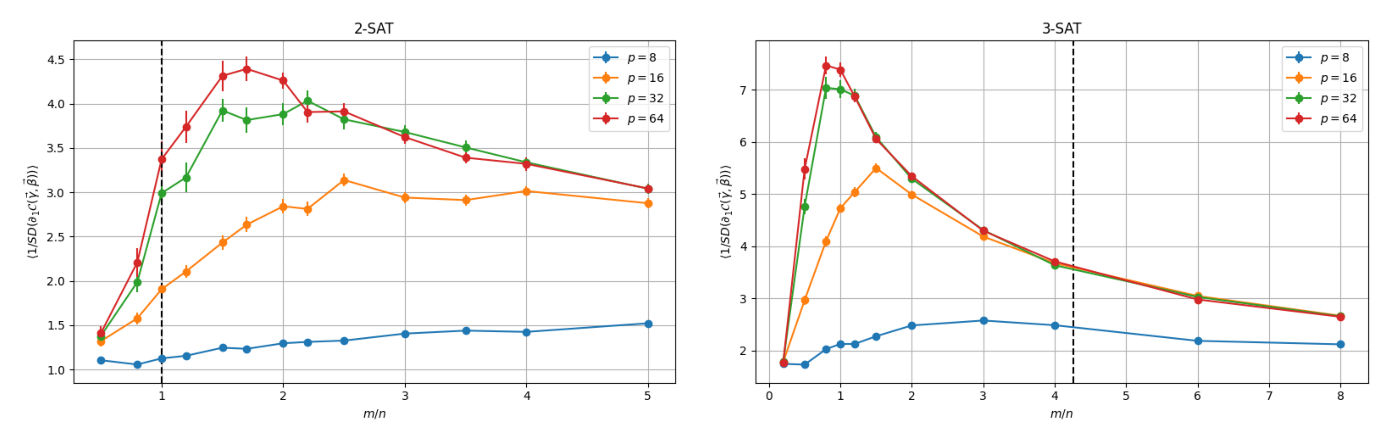

Larger values indicate smaller typical gradients and therefore more difficult optimization.
We see that, when the QAOA depth $p$ is small, this peak is no visible; however, in this regime QAOA also fails to produce accurate solutions, making trainability irrelevant.
For large values of $p$, peaks are clearly visible.
For 2-SAT, the peak is at a clause-to-variable ratio larger than the SAT-UNSAT phase transition ratio.
For 3-SAT, the peak is at a smaller clause-to-variable ratio than the SAT-UNSAT transition ratio.
Recall that the SAT-UNSAT phase transition ratio corresponds to the region of maximum empirical hardness for classical algorithms.
Thus we see that the empirical hardness for QAOA is different from classical algorithms.
Although this result holds for SAT problem, we expect the __computational__ phase transition in QAOA to apply to all
combinatorial optimization problems. In particular, as 3-SAT is NP-complete, the clause-to-variable ratio represents a universal characterization of a ‘problem density’, and the computational phase transition applies to all NP-complete problems in this regard. 

### Heuristic Parameter Initialization

Starting the parameter optimization from random initial conditions for every circuit is computationally expensive, especially for high depths $p$, considering that the corresponding parameter space has dimension $2p$. To avoid this, we implemented a heuristic initialization of parameters based on a layer-wise training approach. The idea consists of using the optimal parameters obtained through the optimization of a circuit with $p$ layers as the starting point for the optimization of a new circuit with $p + \Delta p$ layers. 

This strategy helps prevent the optimization algorithm from getting stuck in local minima or encountering **barren plateaus** when working with circuits characterized by a higher number of layers.

```python
def expand_qaoa_params(old_params, p_old, p_new):
    """Expands the optimal parameters from an arbitrary depth p_old to p_new.
    
    Respects Qiskit's parameter ordering: [beta_0..beta_p, gamma_0..gamma_p].
    Missing layers are initialized with a small uniform noise near zero.

    Args:
        old_params (np.ndarray): The optimized parameters from the previous depth.
        p_old (int): The previous QAOA depth.
        p_new (int): The new, larger QAOA depth.

    Returns:
        np.ndarray: An expanded parameter array of size 2 * p_new.
    """
    delta_p = p_new - p_old
    
    if delta_p <= 0:
        return old_params
        
    new_params = np.zeros(2 * p_new)
    
    # Extract old betas and gammas
    old_betas = old_params[:p_old]
    old_gammas = old_params[p_old:]
    
    # Generate delta_p new random parameters (small noise) for the new layers
    new_betas_padding = np.random.uniform(-0.01, 0.01, size=delta_p)
    new_gammas_padding = np.random.uniform(-0.01, 0.01, size=delta_p)
    
    # Append the new layers to the old ones
    new_betas = np.append(old_betas, new_betas_padding)
    new_gammas = np.append(old_gammas, new_gammas_padding)
    
    # Reassemble in Qiskit's required order
    new_params[:p_new] = new_betas
    new_params[p_new:] = new_gammas
    
    return new_params
```
This solution is implemented in the `expand_qaoa_params` function. First it checks if the old circuits has indeed a lower number of layers than the new one, then extracts its best $\vec{\gamma}$ and $\vec{\beta}$ vectors. A padding layer is added to the new parameters lists to avoid the presence of parameters equal to zero. The new list is generated at the end using the format required by Qiskit $\{\beta_1,\dots,\beta_p,\gamma_1,\dots,\gamma_p\}$ and then used to initialize the new deeper circuit.

### Optimizers

To optimize the $(\vec{\gamma},\vec{\beta})$ parameters of the circuit different optimizers were implemented and compared.

#### 1. COBYLA
Constrained Optimization BY Linear Approximation (COBYLA) is a derivative-free optimization method. It works by iteratively performing a linear approximation of the actual constrained problem. During each iteration, a simplified problem is solved to find a candidate for the optimal solution. This is then tested against the original objective, yielding a new data point in the solution space. The search is refined by progressively reducing the step size, until convergence is reached when the step size becomes sufficiently small.

#### 2. L-BFGS-B
Limited-memory Broyden–Fletcher–Goldfarb–Shanno Bound-constrained (L-BFGS-B) is a quasi-Newton optimization method which estimates both the gradient and the inverse of the Hessian of the objective function. It makes use of the history of the previous steps to approximate the curvature. It is mostly suitable for optimization problems with smooth objective functions, since it relies on high-precision measurements of the gradient.
In the actual optimization phase, this method can be implemented in two different ways, based on whether we do or do not pass the `jac` parameter to `scipy.optimize.minimize` with `method="L-BFGS-B"`:
* if we do pass the `jac` parameter the algorithm will calculate the exact gradients analytically,
* if we do not pass the `jac` parameter the algorithm will compute an estimate of the gradients by computing the finite difference of the objective function: it will introduce a small perturbation in the parameters and calculate the energy variation to approximate the direction of the gradient.

To provide the flexibility of switching between analytical and numerical gradients, the `QAOA_SATsolver` function accepts two distinct optimizer strings: `"L-BFGS-B_grad"`, which computes the exact analytical gradient using the parameter-shift rule, and `"L-BFGS-B"`, which relies on the numerical finite-difference approximation.


#### 3. SPSA
Simultaneous Perturbation Stochastic Approximation (SPSA) is a stochastic approximation algorithm which uses only two objective function measurements per iteration regardless of the dimension of the optimization problem. These measurements are made by randomly perturbing all the variables in the problem and identifying the descent direction. This algorithm is efficient in high-dimensional problems, because the number of measurements required is independent of the number of parameters. Moreover, it is widely used in quantum computing because it is highly resilient to noise, a typical feature of both real quantum hardware and quantum simulators.

Since we're dealing with a stochastic optimizer, its convergence will not be as smooth as the one of deterministic optimizers like COBYLA and L-BFGS-B. Therefore, a stopping criterion is needed and introduced with the following class:

```python
class SPSA_EarlyStopping:
    """Custom termination checker for the SPSA optimizer to implement early stopping."""

    def __init__(self, patience=25, tol=1e-3, min_steps=1500):
        """
        Args:
            patience (int, optional): The sliding window size to evaluate convergence. Defaults to 25.
            tol (float, optional): The tolerance for the change in cost function. Defaults to 1e-3.
            min_steps (int, optional): The minimum number of steps before early stopping can trigger. Defaults to 1500.
        """
        self.patience = patience
        self.tol = tol
        self.min_steps = min_steps
        self.history = []
        self.steps = 0

    def __call__(self, nfev, parameters, value, stepsize, accepted):
        """Evaluates whether the optimization should stop.

        Args:
            nfev (int): Number of function evaluations.
            parameters (np.ndarray): Current parameter values.
            value (float): Current objective function value.
            stepsize (float): Current step size.
            accepted (bool): Whether the step was accepted.

        Returns:
            bool: True if the optimizer should stop, False otherwise.
        """
        self.steps += 1
        self.history.append(value)
        
        if len(self.history) > self.patience:
            self.history.pop(0) 
            if self.steps > self.min_steps:
                window_spread = max(self.history) - min(self.history)
                if window_spread < self.tol:
                    return True 
                
        return False
```
This early stopping criterion evaluates the maximum variation of the objective function across a rolling window of `patience=25` iterations. If this variation falls below `tol=1e-3`, it indicates that the optimizer is stuck either in a minimum or in a plateau without making significant progress, and the algorithm halts. Finally, a `min_steps=1500` parameter ensures that the optimization process is not terminated prematurely.


### Simulation Engine

The simulated circuit is created through the **QAOA_SATsolver** function.

```python
def QAOA_SATsolver(
        formula,
        p,
        optimizer="L-BFGS-B",
        steps_optim=1000,
        initial_params=None,
        seed=None,
        verbose=False,
        trial_idx=None
    ):
    """Builds and optimizes a QAOA circuit for a given SAT formula.

    How it works:
    1. Transforms the SAT formula into a diagonal cost Hamiltonian (SparsePauliOp).
    2. Builds the parameterized QAOA ansatz circuit using Qiskit.
    3. Defines a cost function using EstimatorV2 to evaluate the expectation value of the Hamiltonian.
    4. Minimizes the cost function using the specified classical optimizer.

    Args:
        formula (list): The SAT formula to solve.
        p (int): The depth of the QAOA circuit.
        optimizer (str, optional): The classical optimizer to use ('COBYLA', 'L-BFGS-B', 'L-BFGS-B_grad', or 'SPSA'). Defaults to "L-BFGS-B".
        steps_optim (int, optional): Maximum number of iterations for the optimizer. Defaults to 1000.
        initial_params (np.ndarray, optional): Initial parameters for the circuit. Defaults to None.
        seed (int, optional): Random seed for reproducibility. Defaults to None.
        verbose (bool, optional): Whether to print progress logs. Defaults to False.
        trial_idx (int, optional): The index of the current trial for tracking. Defaults to None.

    Returns:
        dict: A dictionary containing the optimization results (energy, execution time, optimal parameters).
    """
```
Here the initialized parameters are just an example. The true parameters were always specified in our "control panel" script `multiSAT.py`. If not specified, the initial parameters are sampled uniformly out of a small range of values $[0,0.1)$.

The core simulation mechanics are defined within the `gridsearch_QAOA_SATsolver` function defined as follows:
```python
def gridsearch_QAOA_SATsolver(
        k,
        num_vars,
        p_values, 
        m_values, 
        n_trials=50,
        trial_start=0,
        optimizer="L-BFGS-B",
        steps_optim=1000,
        n_jobs=-1, 
        verbose=False,
        dir_name="results",
        run_name="default_run"
    ):
    """Executes a parallel grid search over different formula densities and QAOA depths.

    How it works:
    1. Distributes multiple trials across available CPU cores using Joblib.
    2. Inside each worker, generates a deterministic SAT formula based on a specific seed.
    3. Calculates the exact maximum number of satisfiable clauses (C_max) classically.
    4. Iterates through the sorted p_values (QAOA depths), optimizing the circuit for each depth 
       over the same formula in each CPU.
    5. Implements Heuristic Initialization: the optimal parameters from depth p are 
       expanded and passed as the initial starting point for depth p+delta_p, significantly 
       speeding up convergence and avoiding barren plateaus.
    6. Aggregates and saves the results into a CSV and metadata JSON.

    Note: 
        BEFORE RUNNING THIS FUNCTION REMEMBER TO SET:
        os.environ["OMP_NUM_THREADS"] = "1"
        os.environ["OPENBLAS_NUM_THREADS"] = "1"
        os.environ["MKL_NUM_THREADS"] = "1"
        os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
        os.environ["NUMEXPR_NUM_THREADS"] = "1" 
        This prevents thread oversubscription between Scipy and Joblib.

    Args:
        k (int): Number of literals per clause (e.g., 2 or 3).
        num_vars (int): Number of variables (qubits).
        p_values (list): A list of QAOA depths to test. Must be sorted for proper heuristic initialization.
        m_values (list): A list of the number of clauses to test.
        n_trials (int, optional): Number of random formula instances per density. Defaults to 50.
        trial_start (int, optional): The starting index for the trial. Useful for resuming runs. Defaults to 0.
        optimizer (str, optional): The classical optimizer to use. Defaults to "L-BFGS-B".
        steps_optim (int, optional): Maximum optimization steps. Defaults to 1000.
        n_jobs (int, optional): Number of CPU cores to use for parallelization. Defaults to -1 (all).
        verbose (bool, optional): Print debug logs. Defaults to False.
        dir_name (str, optional): The folder where results will be saved. Defaults to "results".
        run_name (str, optional): The prefix name for the output files. Defaults to "default_run".

    Returns:
        tuple: A tuple containing the aggregated results DataFrame and the run metadata dictionary.
    """
```
It takes all the crucial parameters required for a run. The first operation this function performs is creating a dictionary to store the metadata initialized with those specific parameters.

The computational engine of the simulation is the `worker` function, which defines the tasks each CPU core must execute. To ensure complete reproducibility, even in the event of disconnections or crashes of the virtual machines, a deterministic seed was implemented by hashing every combination of $(m, \text{trial index})$, where the trial index identifies a specifically generated formula. This approach allowed us to easily distribute the workload across different computers by assigning each one a subset of formulas generated with these specific seeds.

```python
def worker(m, trial_idx):
        # Generate a deterministic seed based on m and trial index
        seed_string = f"m{m}_t{trial_idx}"
        trial_seed = int(hashlib.md5(seed_string.encode()).hexdigest(), 16) % (2**32)
        
        gen = kSATGenerator(k=k, seed=trial_seed)
        formula = gen.generate(num_clauses=m, num_vars=num_vars)
        c_max = exact_maxsat(formula, num_vars) 
        
        results_for_this_formula = []
        current_initial_params = None
        current_p = 0
        
        # Heuristic Initialization
        for p in sorted(p_values):
            if current_initial_params is None:
                rng = np.random.default_rng(trial_seed)
                current_initial_params = rng.uniform(0, 0.1, size=2*p)
            else:
                # Expand parameters to match the new depth p
                current_initial_params = expand_qaoa_params(current_initial_params, current_p, p)
            
            result = QAOA_SATsolver(
                formula=formula,
                p=p,
                optimizer=optimizer,
                steps_optim=steps_optim,
                initial_params=current_initial_params,
                seed=trial_seed,
                verbose=verbose,
                trial_idx=trial_idx
            )
            
            # Save the optimized parameters to initialize the next p iteration
            current_initial_params = np.array(result["opt_params"])
            current_p = p
            
            del result["opt_params"]

            result["trial"] = trial_idx
            result["C_max"] = c_max
            result["C_qaoa"] = m - result["energy_Hc"]
            result["approx_ratio"] = result["C_qaoa"] / c_max if c_max > 0 else 1.0 

            results_for_this_formula.append(result)
            
        return results_for_this_formula
```

A classical baseline $C_{max}$ is calculated using the `exact_maxsat` function, which serves as the reference to evaluate the performance of the circuit through the approximation ratio $r$. Every worker sorts the list of specified depths $p$ and starts iteratively assigning the initial $(\vec{\gamma},\vec{\beta})$ parameters. The circuit with the lowest $p$ is initialized with random uniform parameters in the range $[0, 0.1]$, while the subsequent ones are initialized using the heuristic initialization described earlier. The `QAOA_SATsolver` is called for each $p$, and its optimized output is saved to be used as the starting point for the next $p$ iteration.

The expected number of satisfied clauses $C_{qaoa}$ is calculated and used to evaluate the circuit performance via the approximation ratio $r = C_{qaoa}/C_{max}$. All this information and other important metadata, like the index of the formula studied in that iteration, are added to the solver output.

The last part of the function sets up the parallelization framework using `joblib.Parallel`. First, a set of instances $(m, \text{trial})$ is created. These instances are dispatched to the available CPU cores to be analyzed in parallel. However, each core will process a single instance iteratively across all $p$ values to preserve the heuristic initialization sequence. Finally, all the simulation data is stored in a `.csv` file with the chosen `run_name`, alongside a corresponding metadata `.json` file.

## **QAOA Results**

In the following paragraphs, we present the QAOA results obtained using the different optimizers discussed in the previous section. All simulations were performed using $n=10$ variables and circuit depths $p \in \{1, 2, 4, 8, 16\}$. The number of clauses, $m$, varied depending on the problem type: for 2-SAT, we used $m \in \{2, 4, 6, 8, 10, 12, 14, 16, 18, 20\}$, while for 3-SAT we used $m \in \{10, 20, 30, 40, 45, 50, 60, 70\}$. In every simulation, 100 independent random formulas were tested for each $(p, m)$ pair to generate meaningful statistics. The only exception was the 3-SAT simulation with the SPSA optimizer, which was limited to 50 formulas.

Each figure contains the plots corresponding to the QAOA results for a specific optimizer. In the first row, we present the mean energy as a function of the problem density, $\alpha$, for each depth $p$. Independent of the optimizer used, an increasing trend is observable: the mean energy rises as the density grows, corresponding to an increasing number of violated clauses. Naturally, higher values of $p$ yield lower mean energies.

In the second row, we present the approximation ratio results for every optimizer except L-BFGS-B.
Each plot includes a vertical dotted line highlighting the theoretical value of the critical density, $\alpha_c$.

### COBYLA

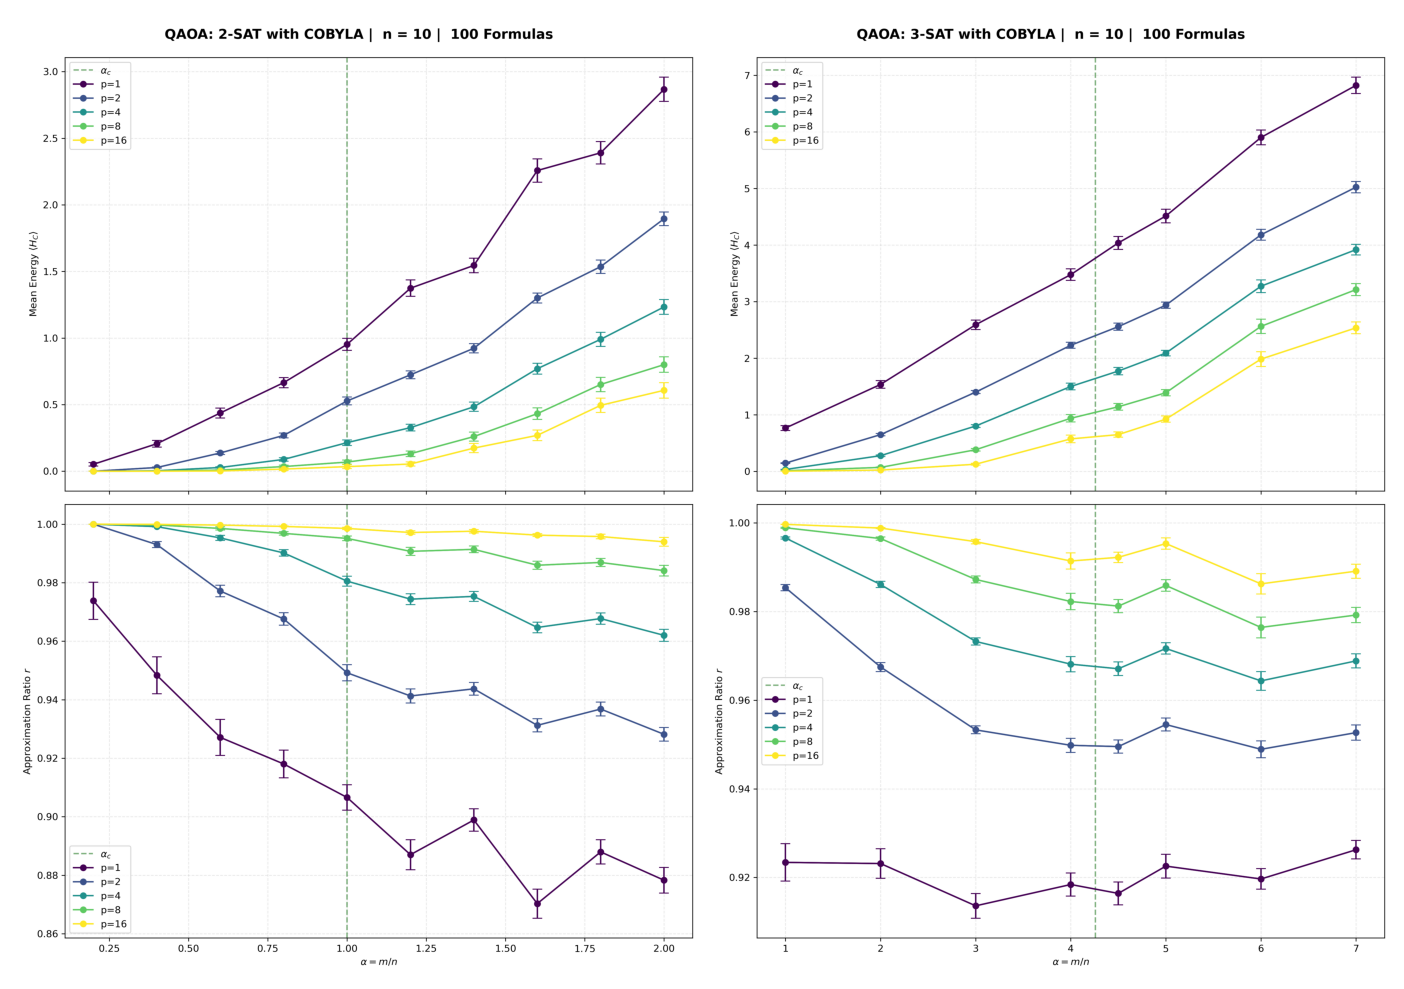

### SPSA

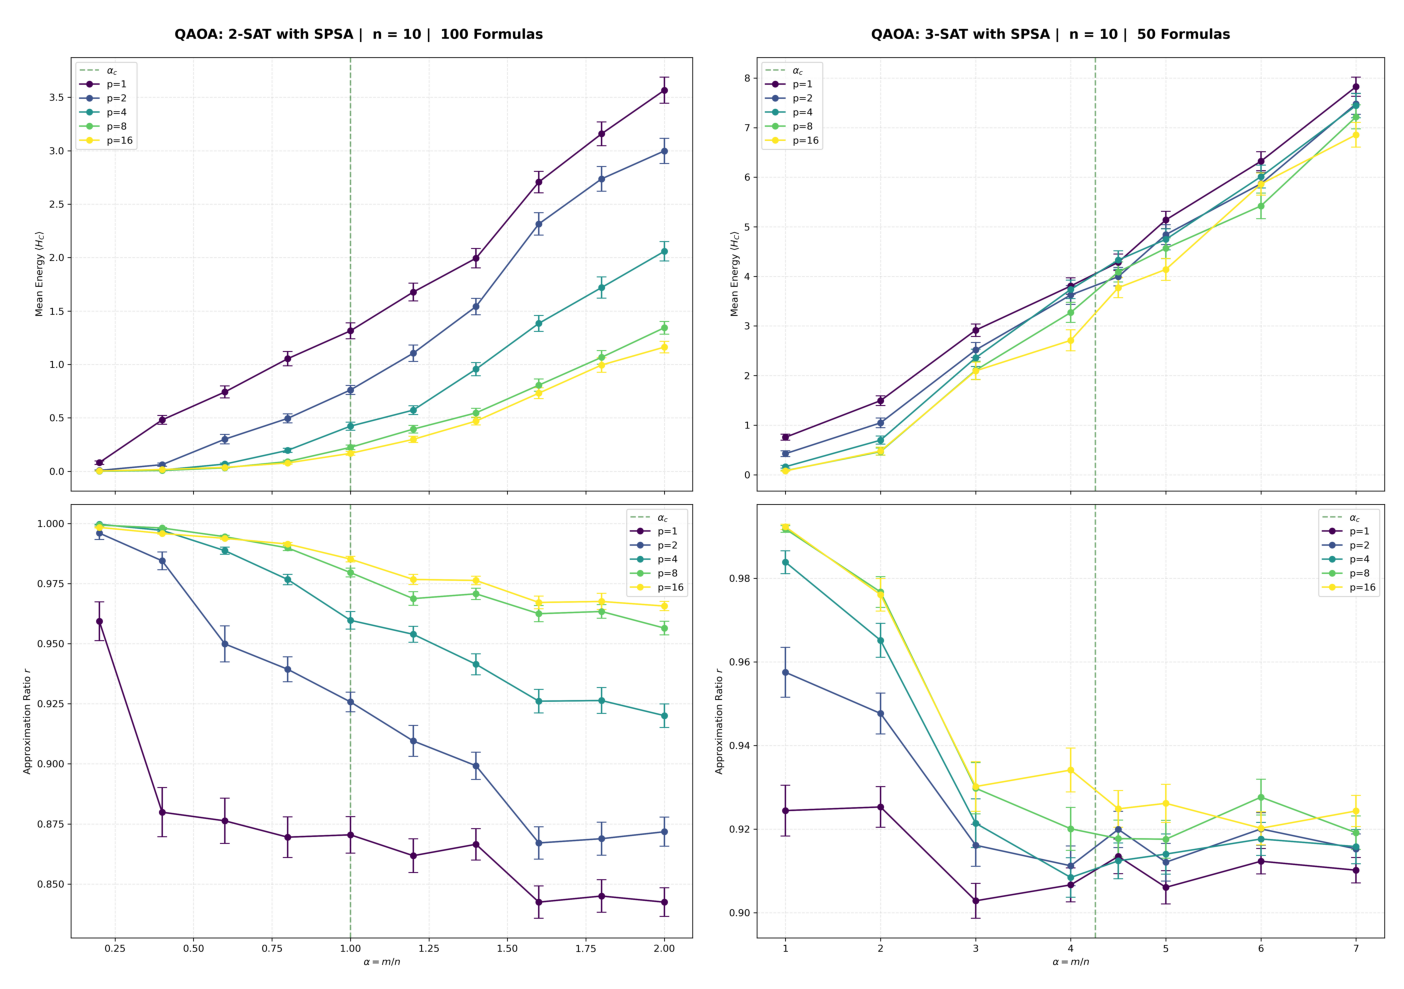

### L-BFGS-B

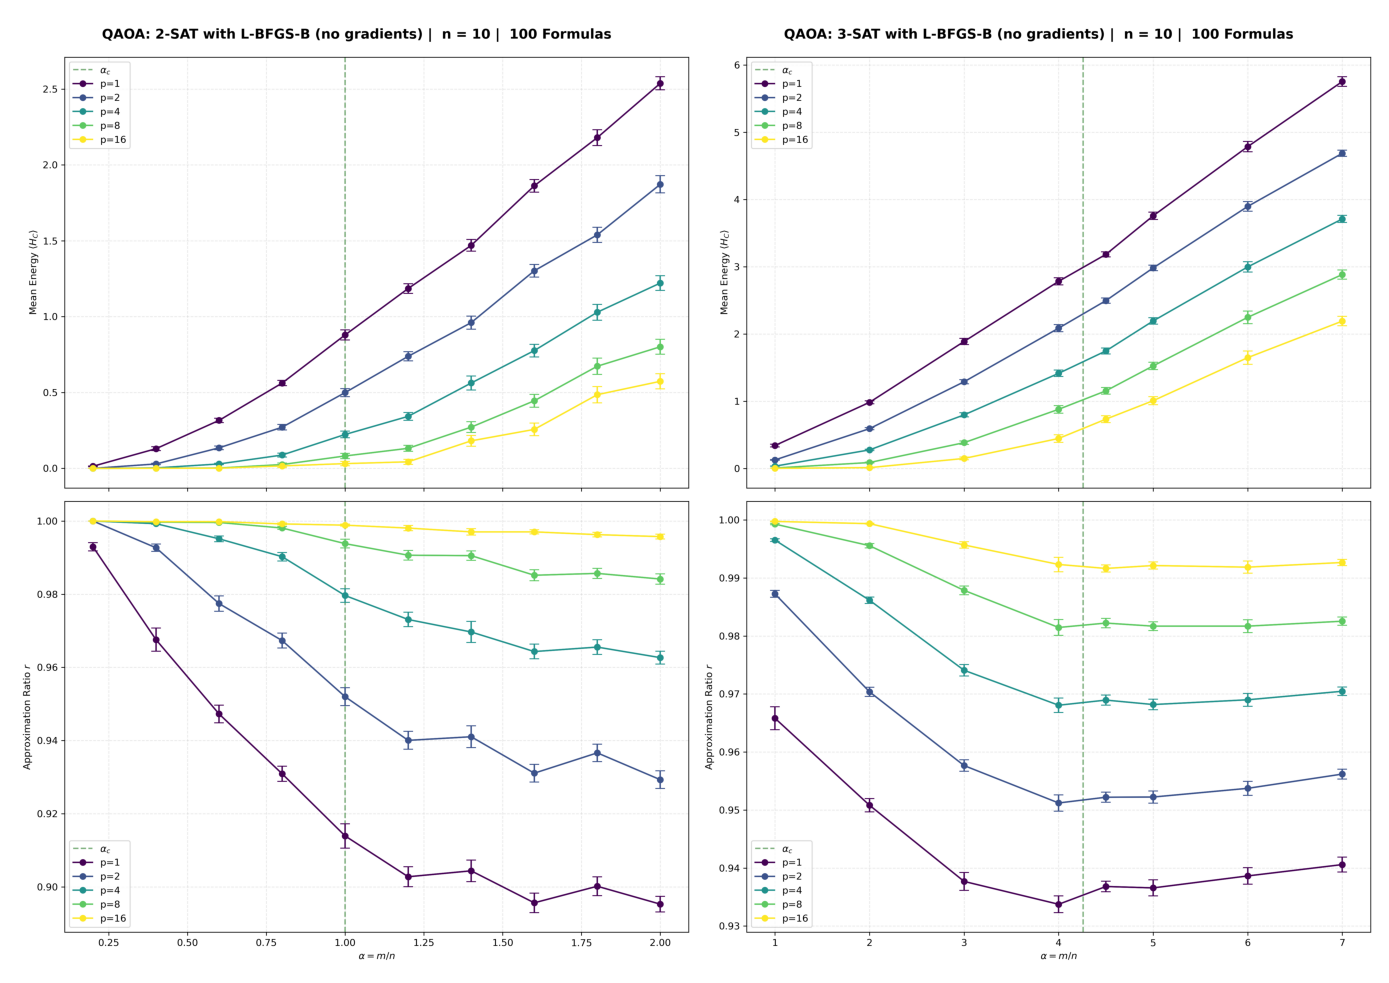

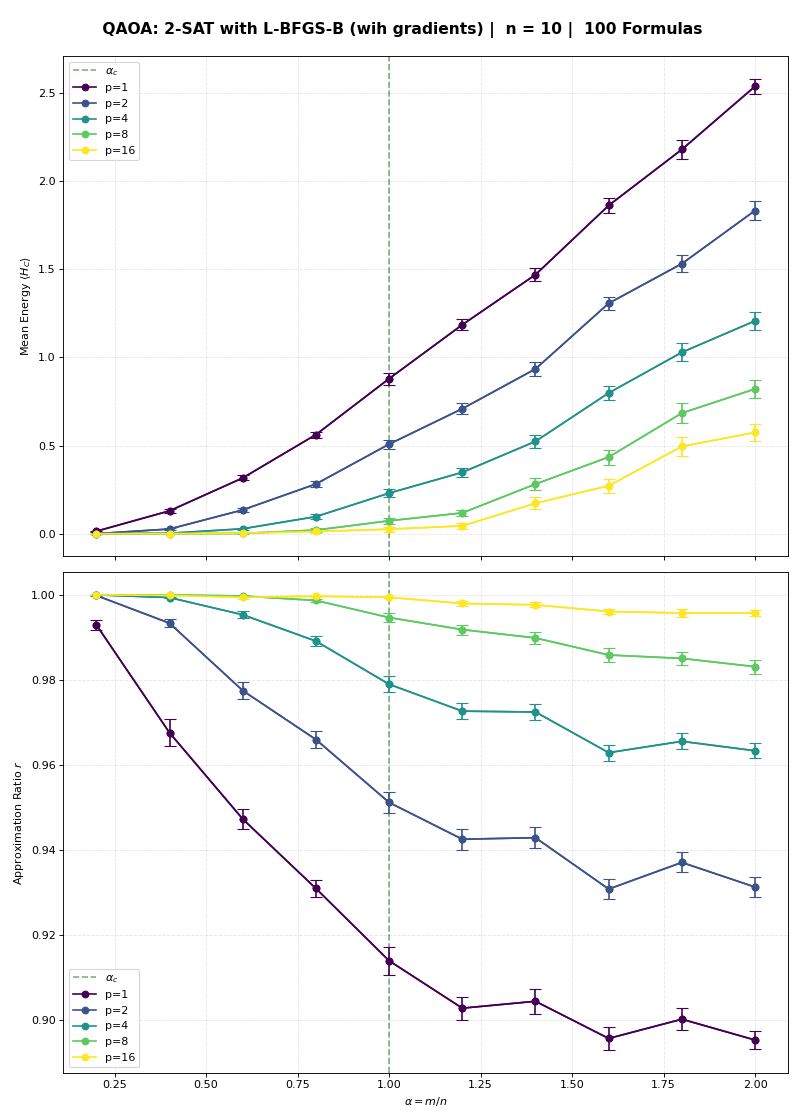

### QAOA Probability of SAT

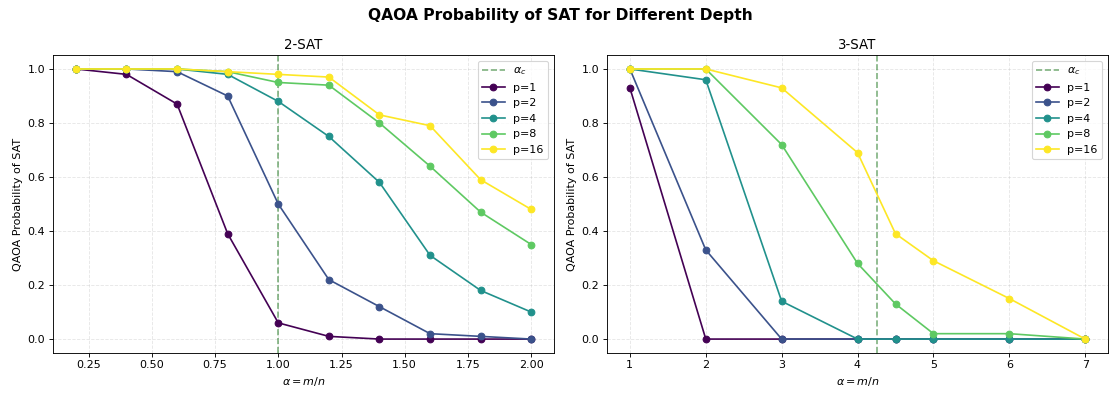

### Comments and Observations on the Results

* **3-SAT SPSA:** Before comparing the results across different optimizers, we must address the anomalous performance of SPSA in the 3-SAT regime. First, the decision to run only fifty instances per $(p,m)$ pair was forced by the enormous execution time required. While cutting the sample size in half when using a stochastic optimizer is not ideal, we believe the poor outcome can be justified by considering the nature of the energy landscape. As we discussed in previous section regarding **Gradient Analysis**, we can infer about the characteristic energy landscape of the 3-SAT problem: the low dispersion of gradient values suggests that the optimizer frequently gets stuck, indicating the probable and abundant presence of barren plateaus and local minima. These considerations explain why a stochastic algorithm like SPSA performs poorly: taking steps in a randomly perturbed parameter space easily leads the optimizer into one of these traps. At this stage, the heuristic parameter initialization may also become detrimental: if the "optimal" parameters recovered from a stuck SPSA run are used to initialize the deeper circuit with $p+\Delta p$ layers, the new optimization starts from a disadvantaged position. This cascading effect likely explains the tangled curves observed in the results. Consequently, we will exclude the 3-SAT SPSA results from further comparative analysis.

* **Gradient vs. No Gradient:** For the 2-SAT problem with the L-BFGS-B optimizer, two almost identical plots are presented. In the first one, we used the built-in **finite differences** as a substitute for a proper gradient evaluation; in the second one, we used the implemented `gradient_function`. To our surprise, there is little to no difference in performance between the two methods. Comparing the huge amount of time it took to simulate the same circuits with the exact gradients to the significantly more reasonable time required without them, it is safe to say that in our case, the analytical gradient proves practically useless. Looking back at how the quantum circuit was implemented and simulated, this outcome could have been predicted considering the complete lack of noise, which is otherwise typical of real quantum hardware. For this precise reason, the finite differences method proves incredibly effective, and its measurements coincide almost exactly with the analytical gradient calculation. Of course, if we were working on a real quantum circuit, the use of exact gradients with Parameter Shift method would have been mandatory to overcome the Shot Noise (i.e., the statistical error margin on the energy measurement) and intrinsic Quantum Noise in general. Because of this, we decided not to simulate the 3-SAT problem using gradients for this optimizer. From this point forward, every consideration and comment on the 2-SAT results concerning this optimizer will automatically refer to the *without gradients* case.

* **Mean Energy:** A comparison of the three optimizers reveals a clear winner: L-BFGS-B shows the best performance for both the 2-SAT and 3-SAT problems. The energy curves for each value of the depth show lower energy values, corresponding to a lower number of violated clauses. For the 2-SAT problem, while COBYLA performs slightly worse than L-BFGS-B with mean energy values higher only by a fraction, the SPSA energies are significantly larger. This is especially true for higher values of $p$, such as $p=16$, where the mean energy is almost two times larger than the one registered in the other two cases at $\alpha=2$. The same can be seen with the 3-SAT problem. Comparing L-BFGS-B and COBYLA yields the same results as before: COBYLA performs slightly worse than its counterpart as the depth increases, except for $p=1$. Comparing these curves for both optimizers, we observe that on average, circuits of this depth optimized with COBYLA find solutions that violate approximately one more clause than the ones found using L-BFGS-B.

* **Approximation Ratio:** The superiority of L-BFGS-B in both simulated problems is confirmed by this metric. In the 2-SAT, high and stable values for $p \in \{8,16\}$ show that using this optimizer allows us to satisfy, respectively, a bit more than $98\%$ and almost $100\%$ of the maximum number of satisfiable clauses found using the brute force method. Other values of $p$ show a more significant descent, but still yield good results with low volatility for each point, as shown by the error bars. Regarding COBYLA, it takes second place with comparable results for $p \in \{4,6,8,16\}$. For the lowest depth, however, the corresponding curve presents a steep descent, with values characterized by high fluctuations for each point. SPSA is confirmed as the worst alternative. For $p=16$, the curve starts lower than the ones referring to $p=8$ and even $p=4$, which is strange, and they all start to point downward before the phase transition. For the two highest values of $p$, moderate overlapping between error bars in a couple of points is observable. Lower values of depth present a consistent increase in volatility, as can be seen with the error bars. For the 3-SAT problem, the distance between L-BFGS-B and COBYLA grows, with the first one showing curves that become almost constant after a brief descent before the phase transition, and that seem to climb back up at larger values of $\alpha$. Every data point is incredibly stable with very little fluctuation. These same features are shown in the COBYLA results, with smaller values and more fluctuations, which makes the curves less stable and wobbly.

* **QAOA Probability of SAT:** We decided to calculate this metric only for the best optimizer. The main idea was to recover the probability of satisfiability calculated classically with the brute force method. We introduced an energy threshold of $0.5$ for the final expectation value $H_C$ of each circuit. For each $(p, m)$ pair, we counted the number of times the measured energy was strictly less than this threshold and divided it by the total number of formulas (i.e., 100). As the depth increases the probaility becomes similar to the one calculted in the classical case. The "best" approximation is obtained with $p=16$. Overall, 2-SAT show better results than 3-SAT, when compared to the classical ones. <br> To acutally compare our results with the classical case, we chose to simulate the 2-SAT and 3-SAT with different numebrs of variable and L-BFGS-B, just for $p=16$, since it was the best approximation. We did the same for the classical solver and graphically compare the results as shown in the next figures:

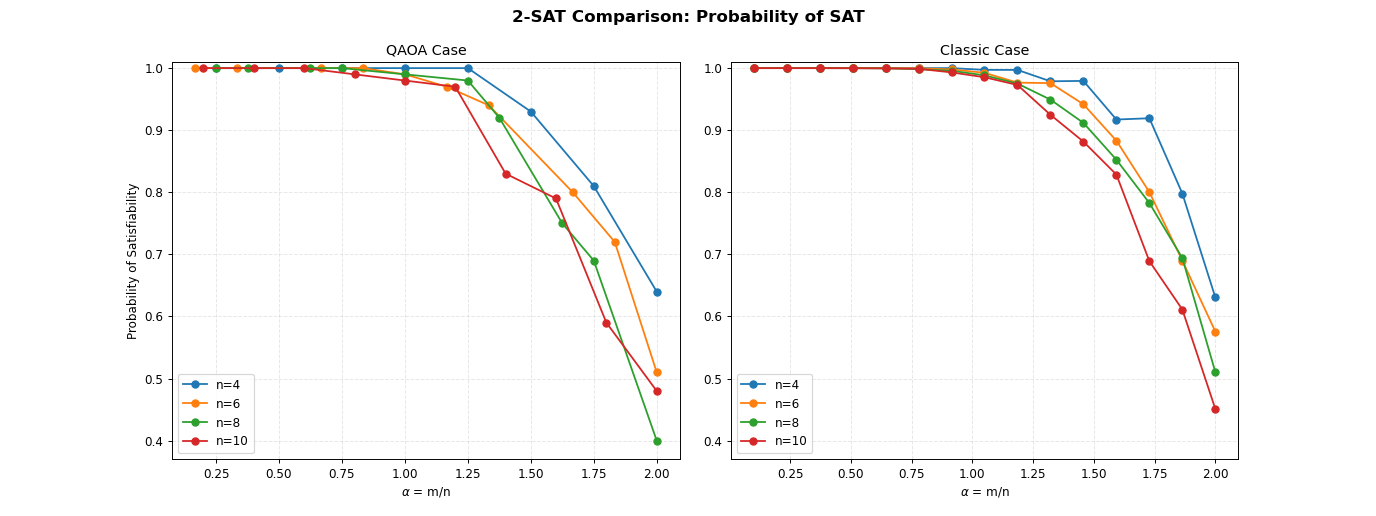

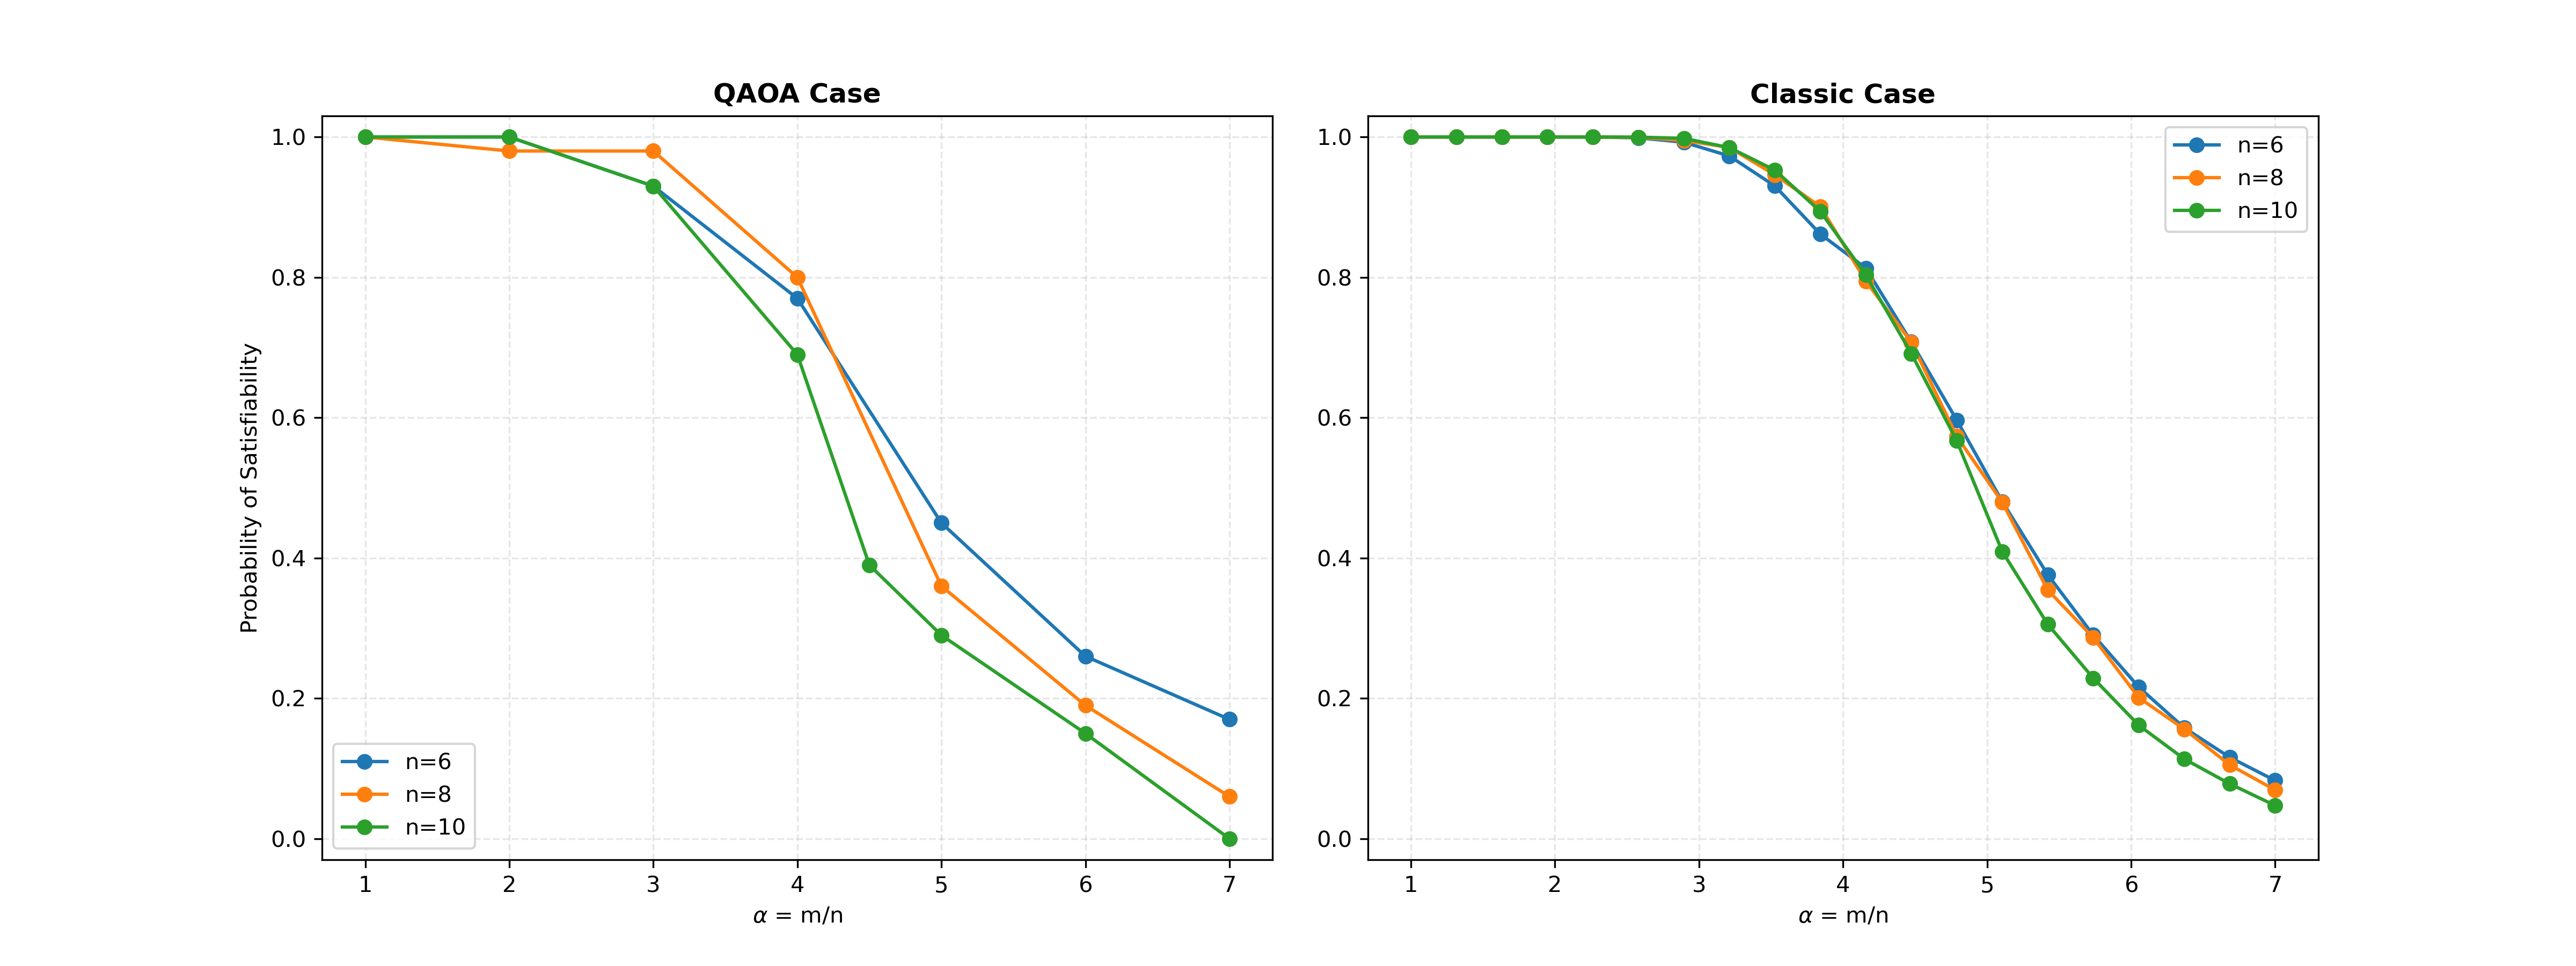

We can see that with larger values of $n$, QAOA approaches the theoretical phase transition curve, becoming steeper. The 2-SAT shows an overall better approximation to the classical case.

## **Conclusions**


Based on the simulations conducted in this study, several key observations can be formulated regarding the performance and behavior of QAOA applied to SAT problems:

* Divergence of Phase Transitions: The classical computational phase transition, which coincides with the actual thermodynamic phase transition, exhibits a fundamentally different behavior compared to the quantum computational phase transition. Interestingly, in the critical regions where the classical computational phase transition takes place, QAOA continues to yield significantly high approximation ratios. Moreover, the quantum computational phase transitions for the 2-SAT and 3-SAT problems are shifted to different critical densities, occurring respectively to the right and to the left of the classical transition boundary.

* Implications for NP-Hard Problems: Given the hardware and simulation constraints, our current results are inherently empirical, having been validated for a finite system size of $n=10$ variables. Nevertheless, if these results were confirmed theoretically for any arbitrary $n$, this would represent a rigorous proof of an intrinsic difference between classical and quantum algorithmic approaches to solving NP-hard problems.

* Consistency with Literature: Ultimately, the data, the approximation capabilities, and the phase transition dynamics extracted from our QAOA simulations are in robust agreement with the findings reported in the paper [Quantum Computational Phase Transition in Combinatorial Problems](https://doi.org/10.48550/arXiv.2109.13346) *(Bingzhi Zhang, Akira Sone, Quntao Zhuang)*.